In [ ]:
# An insurance company wants to estimate a customer's annual medical insurance cost based on their personal and health data. 
# A reliable model helps the underwriting team set fair premiums and flag high-cost customers for closer review.


In [43]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [44]:
# STEP 2: LOAD THE DATA 

df = pd.read_csv('/Users/user/Downloads/insurance.csv')

print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")

Dataset loaded: 1,338 rows x 7 columns


In [45]:
# STEP 3: UNDERSTANDING THE DATA and Rename the Columns

df.columns

# cant rename columns here there is no confusing columns here to rename so we leave it and move to Quick EDA



Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [46]:
# STEP 4: QUICK EDA
# 4a

df.head()             # Preview the first 5 rows — what does the data actually look like?


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [47]:
# 4b

df.shape              # How many rows and columns? (rows, columns)


(1338, 7)

In [48]:
# 4c

df.info()             # Data types and non-null counts — spot wrong types or missing values


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [49]:
# 4d

df.describe()         # Summary statistics for numeric columns — min, max, mean, spread


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [50]:
# 4e

df.isnull().sum()     # Count missing values per column — clean data needs zero


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [51]:
# 4f

df.duplicated().sum() # Count exact duplicate rows — duplicates can bias the model


np.int64(1)

In [52]:
### Data quality issue: 1 duplicate row found

# EDA revealed 1 exact duplicate row across all 7 columns. Since `charges` is a continuous variable with decimal precision, 
# An identical match across all features is almost certainly a data entry error rather than a genuine coincidence. 
    
# Dropping the duplicate to ensure the model is not biased by repeated patterns.

df = df.drop_duplicates()

# Confirm it's gone
print(f"Rows after dropping duplicates: {df.shape[0]:,}")
print(f"Duplicates remaining: {df.duplicated().sum()}")

Rows after dropping duplicates: 1,337
Duplicates remaining: 0


In [53]:
### EDA summary

# The dataset contains 1,338 rows and 7 columns: 4 numeric (age, bmi, children, charges) 
# and 3 categorical (sex, smoker, region). There are no missing values but 1 exact duplicate 
# ow, which has been dropped. 

# Charges range from $1,121 to $63,770 with a mean of $13,270 and a median of $9,382 — 
# indicating a right-skewed distribution with a small number of very high-cost customers 
# pulling the average up. The average BMI of 30.7 falls in the obese range, suggesting 
# this is a higher-risk customer pool. For Project 2, only the numeric features (age, bmi, 
# children) will be used; categorical features (sex, smoker, region) are reserved for 
# Project 4: When one-hot encoding is introduced.

In [54]:
# STEP6: CLEANING DATA 

# Step 5: Cleaning — based on EDA findings, only one issue to fix:
# 1 duplicate row found and dropped.
# No missing values, no wrong types, no impossible values to handle.

df = df.drop_duplicates()

# Confirm
print(f"Rows after cleaning: {df.shape[0]:,}")
print(f"Duplicates remaining: {df.duplicated().sum()}")

Rows after cleaning: 1,337
Duplicates remaining: 0


In [55]:
### Step 6 — Feature Engineering

# No new features will be engineered for this project. With only three numeric 
# features (age, bmi, children), there is little benefit in creating derived 
# columns at this stage. An interaction term like `age × bmi` was considered 
# but rejected: it would be correlated with both parent features (introducing 
# multicollinearity) and would reduce the interpretability of the coefficients, 
# which is the core lesson of this project. Interaction features and bucketing 
# techniques are reserved for later projects with larger feature sets.

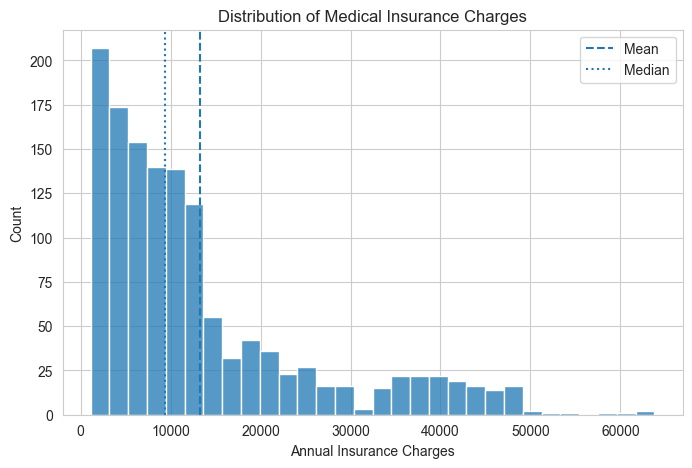

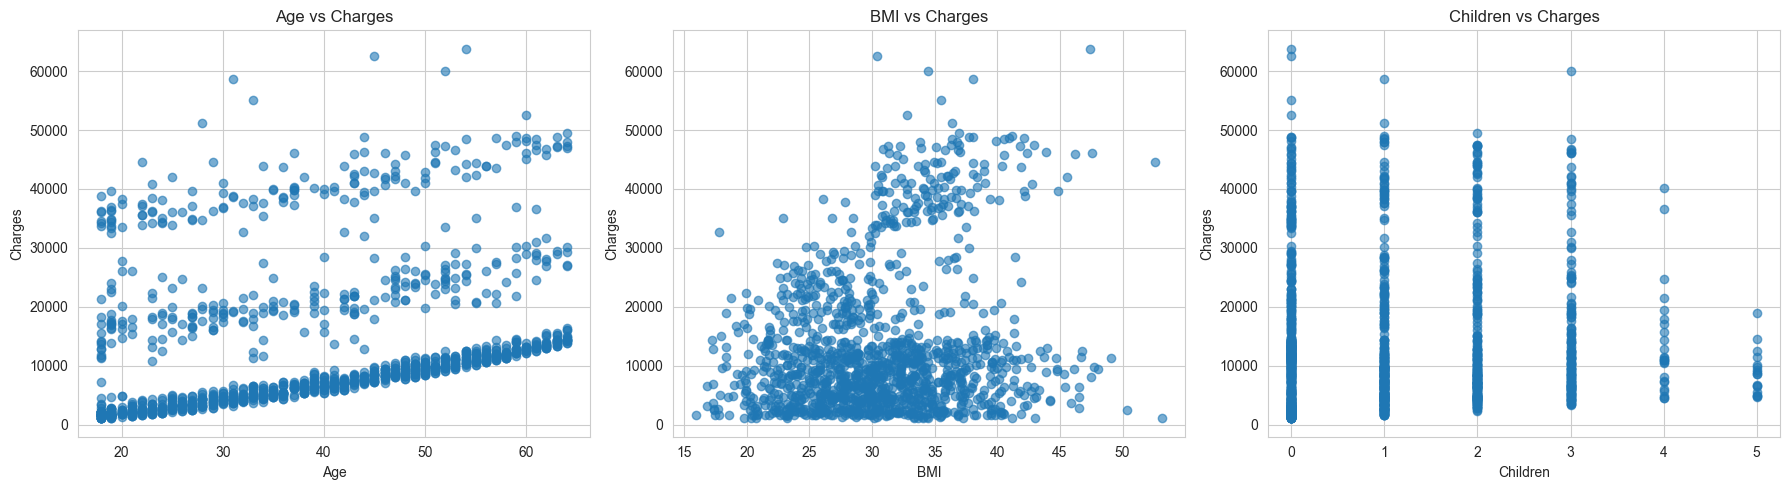

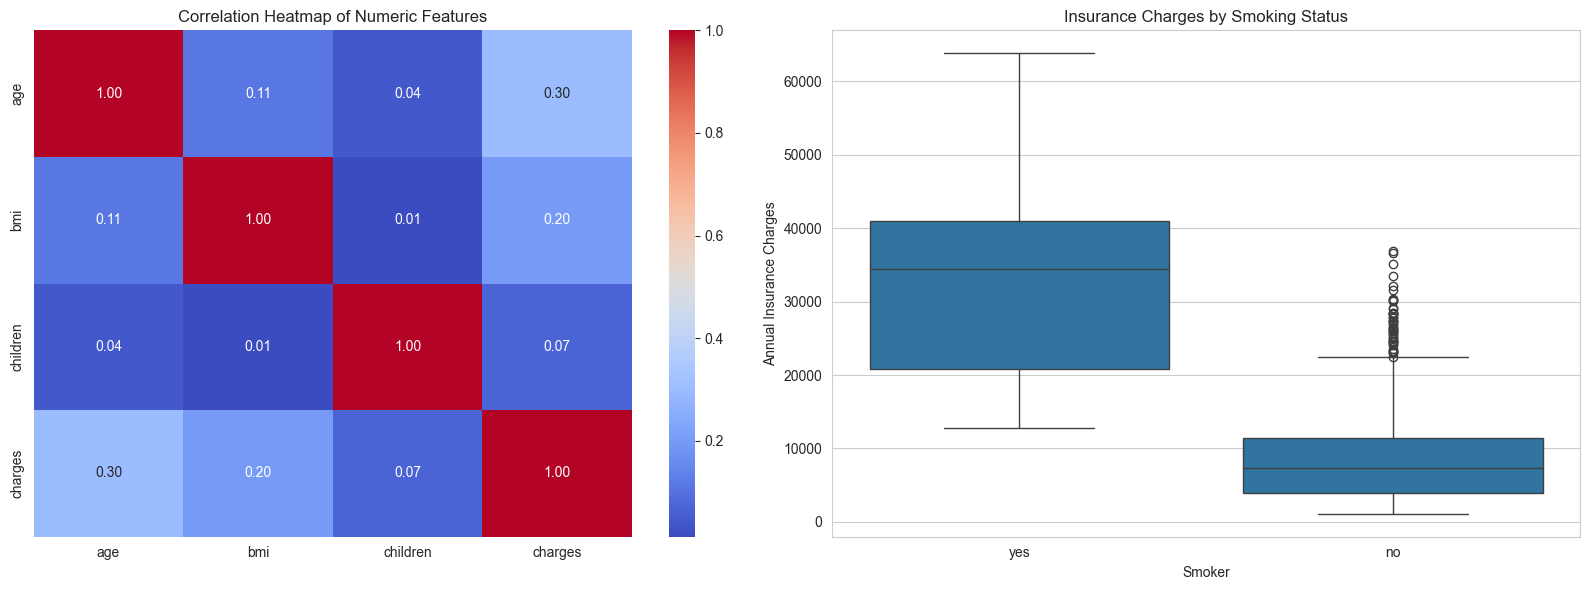

In [56]:
# STEP 7: DEEP EDA

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


# ---------------------------------------------
# Plot 1: Histogram of charges
# Purpose: show the distribution of the target variable
# ---------------------------------------------
plt.figure(figsize=(8, 5))
sns.histplot(df['charges'], bins=30, kde=False)

plt.axvline(df['charges'].mean(), linestyle='--', label='Mean')
plt.axvline(df['charges'].median(), linestyle=':', label='Median')

plt.title('Distribution of Medical Insurance Charges')
plt.xlabel('Annual Insurance Charges')
plt.ylabel('Count')
plt.legend()
plt.show()


# ---------------------------------------------
# Plot 2: Scatter plots of numeric features vs charges
# Purpose: check how each numeric feature relates to charges
# ---------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age vs charges
axes[0].scatter(df['age'], df['charges'], alpha=0.6)
axes[0].set_title('Age vs Charges')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Charges')

# BMI vs charges
axes[1].scatter(df['bmi'], df['charges'], alpha=0.6)
axes[1].set_title('BMI vs Charges')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Charges')

# Children vs charges
axes[2].scatter(df['children'], df['charges'], alpha=0.6)
axes[2].set_title('Children vs Charges')
axes[2].set_xlabel('Children')
axes[2].set_ylabel('Charges')

plt.tight_layout()
plt.show()


# ---------------------------------------------
# Plot 3 and 4 together: Heatmap + Smoker boxplot
# Purpose:
# - Heatmap: check numeric relationships and multicollinearity
# - Boxplot: compare charges for smokers and non-smokers
# ---------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Correlation heatmap
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=axes[0])
axes[0].set_title('Correlation Heatmap of Numeric Features')

# Smoker vs charges boxplot
sns.boxplot(x='smoker', y='charges', data=df, ax=axes[1])
axes[1].set_title('Insurance Charges by Smoking Status')
axes[1].set_xlabel('Smoker')
axes[1].set_ylabel('Annual Insurance Charges')

plt.tight_layout()
plt.show()

In [57]:
### Step 7 — Deep EDA observations

# The histogram of charges confirms a strongly right-skewed distribution, with most 
# customers paying $2,000–$15,000 but a long tail extending to over $60,000. The mean 
# ($13,270) sits well above the median ($9,382), reflecting a small population of 
# high-cost customers pulling the average up.

# Scatter plots reveal three parallel bands in the age vs charges relationship, 
# suggesting a hidden categorical driver of cost (later confirmed to be smoker 
# status via the boxplot. Within each band, age has a clear linear effect.

# The correlation heatmap shows no multicollinearity between the three numeric 
# features (age–bmi correlation is just 0.11), making them safe to use together 
# in regression. However, all three features have weak-to-moderate correlations 
# with charges (max 0.30 for age), suggesting the linear model will only capture 
# part of the cost variation.

# The boxplot reveals smoking status as the strongest known driver — smokers pay 
# roughly 5x more than non-smokers. This feature is intentionally excluded from 
# Project 2's model is reserved for Project 4, which will introduce one-hot 
# encoding of categorical variables.

In [58]:
# STEP 8a — DEFINE FEATURES (X) AND TARGET (y)

# Features = the 3 numeric predictors
X = df[['age', 'bmi', 'children']]

# Target = what we want to predict
y = df['charges']

# Final check
print(X.shape)
print(y.shape)
print(X.head())

(1337, 3)
(1337,)
   age     bmi  children
0   19  27.900         0
1   18  33.770         1
2   28  33.000         3
3   33  22.705         0
4   32  28.880         0


In [59]:
# STEP 8b — TRAIN / TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

X_train: (1069, 3)
X_test:  (268, 3)
y_train: (1069,)
y_test:  (268,)


In [60]:
### Step 8 — Train/test split

# The dataset is split 80/20 into training and test sets. The model will learn 
# from the training set only; the test set is held out as unseen data to give 
# an honest measure of performance. random_state is set to 42, so the split is 
# reproducible — anyone running this notebook will get the same split.

In [61]:
# STEP 8c: TRAIN THE MODEL

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [62]:
# STEP 8d: INSPECT WHAT THE MODEL LEARNED

print(f"Intercept: ${model.intercept_:,.2f}")
print()
print("Coefficients (impact per unit of each feature):")

for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature}: ${coef:,.2f}")

Intercept: $-5,095.38

Coefficients (impact per unit of each feature):
  age: $224.00
  bmi: $281.46
  children: $690.92


In [63]:
# STEP 9: EVALUATE THE MODEL ON UNSEEN TEST DATA

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score: {r2:.4f}")
print(f"MAE: ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")

R² Score: 0.1375
MAE: $9,620.93
RMSE: $12,589.41


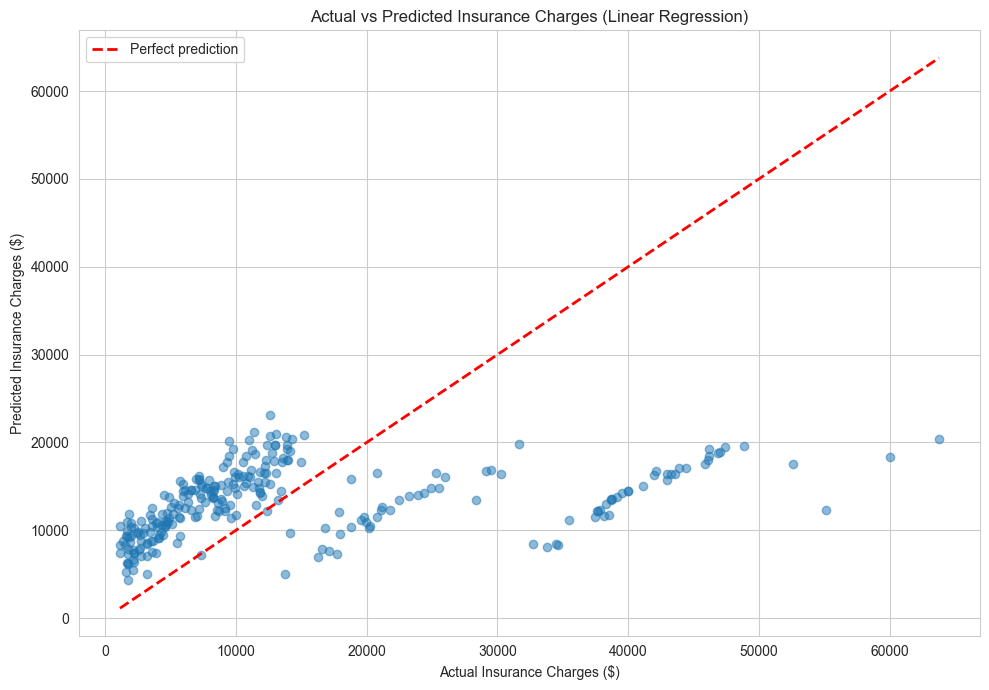

In [64]:
# STEP 10: ACTUAL VS PREDICTED PLOT

plt.figure(figsize=(10, 7))
plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--',
    linewidth=2,
    label='Perfect prediction'
)

plt.xlabel('Actual Insurance Charges ($)')
plt.ylabel('Predicted Insurance Charges ($)')
plt.title('Actual vs Predicted Insurance Charges (Linear Regression)')
plt.legend()
plt.tight_layout()
plt.savefig('insurance_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()